<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Intro_to_Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision for Beginners

Welcome! In this notebook, we will explore the basics of Computer Vision (CV). Computer Vision is the field of Artificial Intelligence that enables computers to "see" and understand digital images and videos.

Today, we will use **OpenCV** (Open Source Computer Vision Library), one of the most popular tools used by engineers and researchers worldwide.

**What we will cover:**
1. Loading and displaying images
2. Understanding Color Spaces (Grayscale)
3. Extracting Features (Edge Detection)
4. AI in Action (Face Detection)

In [21]:
# First, let's import the necessary libraries
import cv2 # OpenCV
import numpy as np # For numerical operations and matrix math
import matplotlib.pyplot as plt # For displaying our images
import urllib.request # To download sample files

# Download a sample image and a face detection model file
image_url = "https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/Lovnish.jpg"
xml_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"

urllib.request.urlretrieve(image_url, "sample.jpg")
urllib.request.urlretrieve(xml_url, "haarcascade_frontalface_default.xml")

print("Setup complete! Libraries imported and files downloaded.")

Setup complete! Libraries imported and files downloaded.


## 1. Loading and Displaying Images
To a computer, an image is just a giant grid of numbers (a matrix). Each number represents the brightness of a specific color at a specific pixel.

Let's load our sample image and take a look.

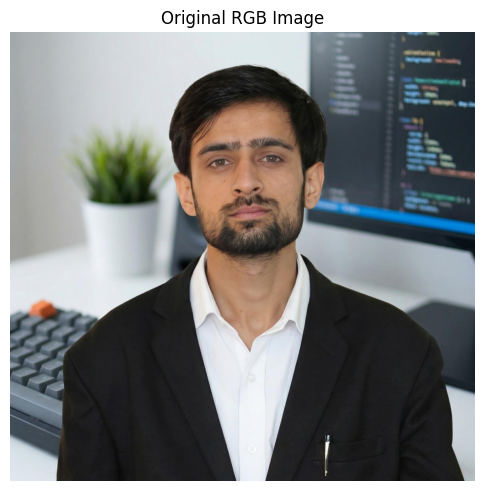

The image shape is: (1274, 1318, 3)


In [22]:
# Read the image using OpenCV
# By default, OpenCV reads images in BGR (Blue, Green, Red) format
img_bgr = cv2.imread("sample.jpg")

# Matplotlib expects RGB (Red, Green, Blue) format, so we need to convert it
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis('off') # Hide the axes for a cleaner look
plt.title("Original RGB Image")
plt.show()

# Let's see the underlying matrix shape: (Height, Width, Color Channels)
print(f"The image shape is: {img_bgr.shape}")

## 2. Color Spaces: Moving to Grayscale
Color is great for human eyes, but it often adds unnecessary complexity for computers trying to understand shapes or structures. Converting an image to grayscale reduces the data by a factor of 3 (from 3 color channels down to 1), making processing much faster.

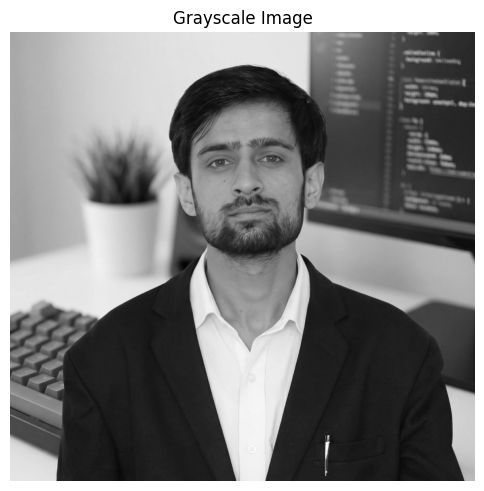

The grayscale image shape is: (1274, 1318)


In [23]:
# Convert the original BGR image to Grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray') # We must specify the colormap as 'gray'
plt.axis('off')
plt.title("Grayscale Image")
plt.show()

print(f"The grayscale image shape is: {img_gray.shape}")

In [24]:
from google.colab import ai
from IPython.display import Markdown, display
response = ai.generate_text("Color Spaces: Moving to Grayscale Using OpenCV")

# Display as Markdown
display(Markdown(response))

Converting a color image to grayscale is a fundamental operation in computer vision. It simplifies the image by removing color information, leaving only intensity values. This can reduce computational complexity, improve performance for certain algorithms, and focus on structural or textural features.

### What is Grayscale?

A grayscale image is an image where the value of each pixel is a single sample, representing only the amount of light or intensity. It typically ranges from black (0) to white (255) for an 8-bit image. Unlike a color image which uses three channels (Red, Green, Blue, or BGR in OpenCV), a grayscale image has only one channel.

### Why Convert to Grayscale?

1.  **Reduced Complexity:** A single channel (grayscale) is simpler to process than three channels (color). This can lead to faster execution for many image processing algorithms.
2.  **Memory Efficiency:** Grayscale images require less memory storage compared to their color counterparts (typically 1/3 the memory).
3.  **Algorithm Requirements:** Many classical computer vision algorithms (e.g., edge detection like Canny, thresholding, some feature detectors like SURF/SIFT) are designed to work on grayscale images.
4.  **Feature Focus:** Sometimes, color information is irrelevant or even distracting for the task at hand. Grayscale images emphasize intensity differences, which can be crucial for identifying shapes, textures, and edges.

### How Grayscale is Formed from Color

When converting a color image (like RGB or BGR) to grayscale, the goal is to derive a single intensity value from the three color components (Red, Green, Blue). There are a few common methods:

1.  **Luma (Weighted Average Method):** This is the most common and perceptually accurate method, often used by `cv2.cvtColor`. It accounts for the human eye's varying sensitivity to different colors. We perceive green light as brighter than red or blue light.
    The formula is typically:
    `Gray = 0.299 * Red + 0.587 * Green + 0.114 * Blue`
    (Note: OpenCV uses BGR, so it would be `0.114 * Blue + 0.587 * Green + 0.299 * Red`)

2.  **Average Method:** Simply takes the average of the three color channels:
    `Gray = (Red + Green + Blue) / 3`

3.  **Lightness Method:** Averages the most prominent and least prominent colors:
    `Gray = (max(Red, Green, Blue) + min(Red, Green, Blue)) / 2`

OpenCV's `cvtColor` function for `COLOR_BGR2GRAY` primarily uses a variant of the Luma method to ensure perceptually uniform results.

### Moving to Grayscale using OpenCV

OpenCV provides a straightforward function, `cv2.cvtColor()`, to convert images between different color spaces, including to grayscale.

#### Key Functions:

*   `cv2.imread(filename, flags)`: Reads an image from a file.
    *   `filename`: Path to the image file.
    *   `flags`:
        *   `cv2.IMREAD_COLOR` or `1` (default): Loads a color image.
        *   `cv2.IMREAD_GRAYSCALE` or `0`: Loads an image directly in grayscale.
        *   `cv2.IMREAD_UNCHANGED` or `-1`: Loads the image as is, including alpha channel if present.
*   `cv2.cvtColor(src, code)`: Converts an image from one color space to another.
    *   `src`: The input image (NumPy array).
    *   `code`: The color space conversion code (e.g., `cv2.COLOR_BGR2GRAY`).
*   `cv2.imshow(winname, mat)`: Displays an image in a window.
*   `cv2.waitKey(delay)`: Waits for a key event.
    *   `0`: Waits indefinitely.
    *   `>0`: Waits for `delay` milliseconds.
*   `cv2.destroyAllWindows()`: Destroys all the windows created by OpenCV.
*   `cv2.imwrite(filename, img)`: Saves an image to a specified file.

---

### Step-by-Step Code Example

Let's illustrate with a Python example:

```python
import cv2
import numpy as np

# --- 1. Define the image path ---
# Make sure to replace 'your_image.jpg' with the actual path to your image file.
# You can download a sample image or use one you have.
image_path = 'path/to/your/image.jpg'

# --- 2. Load the image ---
# Method A: Load as a color image, then convert to grayscale
img_color = cv2.imread(image_path)

# Check if the image was loaded successfully
if img_color is None:
    print(f"Error: Could not load the image from {image_path}")
    print("Please check the path and ensure the image file exists.")
    exit()

print(f"Original image shape (H, W, C): {img_color.shape}")

# --- 3. Convert the color image to grayscale ---
# OpenCV uses BGR (Blue, Green, Red) by default for color images loaded with imread.
# So, we convert from BGR to GRAY.
gray_image_converted = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

print(f"Grayscale (converted) image shape (H, W): {gray_image_converted.shape}")

# --- 4. (Alternative) Load image directly as grayscale ---
# This is often more efficient if you only ever need the grayscale version.
img_gray_direct = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img_gray_direct is None:
    print(f"Error: Could not load the image as grayscale from {image_path}")
    exit()

print(f"Grayscale (direct load) image shape (H, W): {img_gray_direct.shape}")


# --- 5. Display the images ---
cv2.imshow('Original Color Image', img_color)
cv2.imshow('Grayscale Image (Converted)', gray_image_converted)
cv2.imshow('Grayscale Image (Direct Load)', img_gray_direct)

# Wait indefinitely for a key press (0 means wait forever)
# This keeps the windows open until you press any key.
cv2.waitKey(0)

# Destroy all OpenCV windows to free up resources
cv2.destroyAllWindows()


# --- 6. Save the grayscale image ---
output_path = 'grayscale_output.jpg'
cv2.imwrite(output_path, gray_image_converted)
print(f"Grayscale image saved to {output_path}")

# You can also save the directly loaded grayscale image
cv2.imwrite('grayscale_direct_load.png', img_gray_direct)
print(f"Directly loaded grayscale image saved to grayscale_direct_load.png")
```

---

### Explanation of the Code:

1.  **`image_path = 'path/to/your/image.jpg'`**:
    *   **Crucial:** You must change this to the actual path of an image file on your computer. If the image is in the same directory as your Python script, just `image.jpg` will work.

2.  **`img_color = cv2.imread(image_path)`**:
    *   This loads your image. By default, `imread` loads color images in BGR format (Blue, Green, Red channel order).
    *   The `if img_color is None:` block is important for error handling. If `imread` can't find or load the image, it returns `None`.

3.  **`print(f"Original image shape... {img_color.shape}")`**:
    *   For a color image, `img_color.shape` will typically return `(height, width, 3)`, indicating height, width, and 3 color channels.

4.  **`gray_image_converted = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)`**:
    *   This is the core conversion step.
    *   `img_color`: The input color image.
    *   `cv2.COLOR_BGR2GRAY`: This is the conversion code. It tells OpenCV to convert an image from BGR color space to grayscale. If your image was loaded in RGB (e.g., from another library or explicitly converted), you'd use `cv2.COLOR_RGB2GRAY`.

5.  **`print(f"Grayscale (converted) image shape... {gray_image_converted.shape}")`**:
    *   For a grayscale image, `gray_image_converted.shape` will typically return `(height, width)`, indicating only height and width, as there's only one channel.

6.  **`img_gray_direct = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)`**:
    *   This demonstrates an alternative: loading the image *directly* as grayscale from the file. This can be more efficient if you *only* need the grayscale version, as OpenCV doesn't have to load all color data and then convert.

7.  **`cv2.imshow(...)`, `cv2.waitKey(0)`, `cv2.destroyAllWindows()`**:
    *   These lines are standard for displaying images with OpenCV. `imshow` creates windows, `waitKey(0)` pauses the script indefinitely until a key is pressed, and `destroyAllWindows` closes all open OpenCV windows.

8.  **`cv2.imwrite(output_path, gray_image_converted)`**:
    *   Saves the resulting grayscale image to a new file named `grayscale_output.jpg`.

This guide provides a comprehensive overview and practical implementation for working with grayscale images in OpenCV, covering both the "why" and the "how."

## 3. Extracting Features: Edge Detection
How do we find objects in an image? We look for boundaries. Edges occur where there is a sharp change in pixel brightness (e.g., a dark object against a light background).

We will use the **Canny Edge Detector**, a classic and highly effective algorithm.

In [25]:
from google.colab import ai
from IPython.display import Markdown, display
response = ai.generate_text("Canny Edge Detector")

# Display as Markdown
display(Markdown(response))

The **Canny Edge Detector** is a widely used and highly effective algorithm for detecting a wide range of edges in images. Developed by John F. Canny in 1986, it is celebrated for its ability to balance three key criteria for optimal edge detection:

1.  **Low Error Rate:** Detecting most real edges and avoiding false positives.
2.  **Good Localization:** The detected edges should be as close as possible to the true edges.
3.  **Minimal Response:** Only one response (one edge pixel) for each actual edge.

The Canny algorithm achieves this through a multi-stage process:

---

### The 5 Steps of the Canny Edge Detector

1.  **Noise Reduction (Smoothing)**
    *   **Purpose:** Edges are high-frequency components, but so is noise. To prevent noise from being misinterpreted as edges, the image is first smoothed.
    *   **Method:** A **Gaussian filter** is applied to the image. The Gaussian kernel blurs the image, effectively removing high-frequency noise while preserving most of the important edge information.
    *   **Parameter:** The standard deviation ($\sigma$) of the Gaussian kernel. A larger $\sigma$ leads to more blurring and less noise, but can also blur out fine details and weak edges.

2.  **Gradient Calculation (Finding Intensity Gradients)**
    *   **Purpose:** To detect potential edge points by identifying areas of significant intensity change.
    *   **Method:** The smoothed image is filtered with a pair of **Sobel operators** (or similar gradient operators like Prewitt or Roberts) to calculate the gradient in the horizontal ($G_x$) and vertical ($G_y$) directions.
        *   $G_x = \text{Image} * \begin{pmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{pmatrix}$
        *   $G_y = \text{Image} * \begin{pmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{pmatrix}$
    *   **Outputs:**
        *   **Edge Magnitude:** The strength of the edge at each pixel, calculated as $G = \sqrt{G_x^2 + G_y^2}$.
        *   **Edge Direction:** The orientation of the edge (perpendicular to the gradient direction), calculated as $\theta = \text{atan2}(G_y, G_x)$. The direction is usually rounded to one of four common directions: 0°, 45°, 90°, or 135°.

3.  **Non-Maximum Suppression (NMS)**
    *   **Purpose:** To thin the edges, ensuring that only one thin line of pixels represents an edge, achieving the "single response" criterion. The gradient magnitude often produces thick ridges of pixels where an edge exists.
    *   **Method:** For every pixel in the gradient magnitude image, it compares its magnitude to the magnitudes of its two neighbors along the *gradient direction* (which was calculated in the previous step).
        *   If the pixel's magnitude is *not* greater than both of its neighbors along the gradient direction, it is suppressed (its magnitude is set to 0). Otherwise, it is kept as a potential edge pixel.
    *   **Example:** If the gradient direction is horizontal (0°), a pixel's magnitude is compared with its left and right neighbors. If the direction is 45°, it's compared with its top-left and bottom-right neighbors, and so on.

4.  **Hysteresis Thresholding**
    *   **Purpose:** To finalize the edge map by distinguishing between strong, weak, and non-edges, and connecting weak edges that are part of a stronger edge. This handles the problem of a single threshold leading to either too many false positives or too many missed edges.
    *   **Method:** Two thresholds are used:
        *   **`high_threshold`:** Any pixel with a gradient magnitude *above* this threshold is immediately classified as a **strong edge** pixel (and kept).
        *   **`low_threshold`:** Any pixel with a gradient magnitude *below* this threshold is immediately classified as a **non-edge** pixel (and discarded).
        *   **Intermediate Pixels:** Pixels with magnitudes *between* `low_threshold` and `high_threshold` are classified as **weak edges**. They are kept *only if* they are connected to a strong edge pixel. This is typically done by performing a connected components analysis or a "flood fill" operation starting from the strong edges. If a weak edge pixel cannot be reached from a strong edge, it's discarded.
    *   **Benefit:** This approach helps in connecting fragmented edge segments and reducing spurious edges caused by noise.

---

### Advantages of Canny Edge Detection:

*   **Robust to Noise:** Gaussian smoothing effectively reduces noise before gradient calculation.
*   **Good Localization:** Edges are detected accurately at their true positions.
*   **Thin Edges:** Non-Maximum Suppression ensures edges are one pixel wide.
*   **High Accuracy:** Generally performs very well across a wide variety of images.
*   **Continuous Edges:** Hysteresis thresholding helps in producing more complete and continuous edge lines.

### Disadvantages:

*   **Computational Cost:** It's more computationally intensive than simpler edge detectors (like Sobel or Prewitt).
*   **Parameter Sensitivity:** The choice of `sigma` for the Gaussian filter and the `low_threshold` and `high_threshold` values can significantly impact the results and often requires careful tuning for specific applications.

---

### Applications:

Canny edge detection is a fundamental tool in computer vision and is used in various applications, including:
*   Object Recognition and Detection
*   Feature Extraction
*   Image Segmentation
*   Medical Imaging
*   Autonomous Driving
*   Machine Vision for Quality Control

---

### Example in Python (using OpenCV):

```python
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = 'path/to/your/image.jpg' # Replace with your image path
try:
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
except FileNotFoundError as e:
    print(e)
    # Use a placeholder image if loading fails
    # Create a simple checkerboard pattern for demonstration
    import numpy as np
    image = np.zeros((200, 200, 3), dtype=np.uint8)
    image[0:100, 0:100] = [255, 255, 255] # White top-left
    image[100:200, 100:200] = [255, 255, 255] # White bottom-right
    print("Using a placeholder image for demonstration.")


# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Canny Edge Detector
# Parameters:
# 1. Grayscale image
# 2. Low threshold (for hysteresis)
# 3. High threshold (for hysteresis)
# 4. Aperture size for the Sobel operator (default 3, can be 3, 5, or 7)
# 5. L2gradient: Boolean flag. If true, uses L2 norm for gradient magnitude (sqrt(Gx^2 + Gy^2)),
#    otherwise uses L1 norm (|Gx| + |Gy|). L2 is generally more accurate.
edges = cv2.Canny(gray_image, 100, 200, apertureSize=3, L2gradient=True)

# Display the original and edge-detected images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.show()
```

In the OpenCV `cv2.Canny()` function:
*   The Gaussian smoothing and gradient calculation (Sobel) are handled internally.
*   You directly provide the `low_threshold` and `high_threshold` values for the hysteresis step.
*   `apertureSize` relates to the size of the Sobel kernel (e.g., 3x3, 5x5, etc.).
*   `L2gradient` determines if the L1 or L2 norm is used for calculating the gradient magnitude.

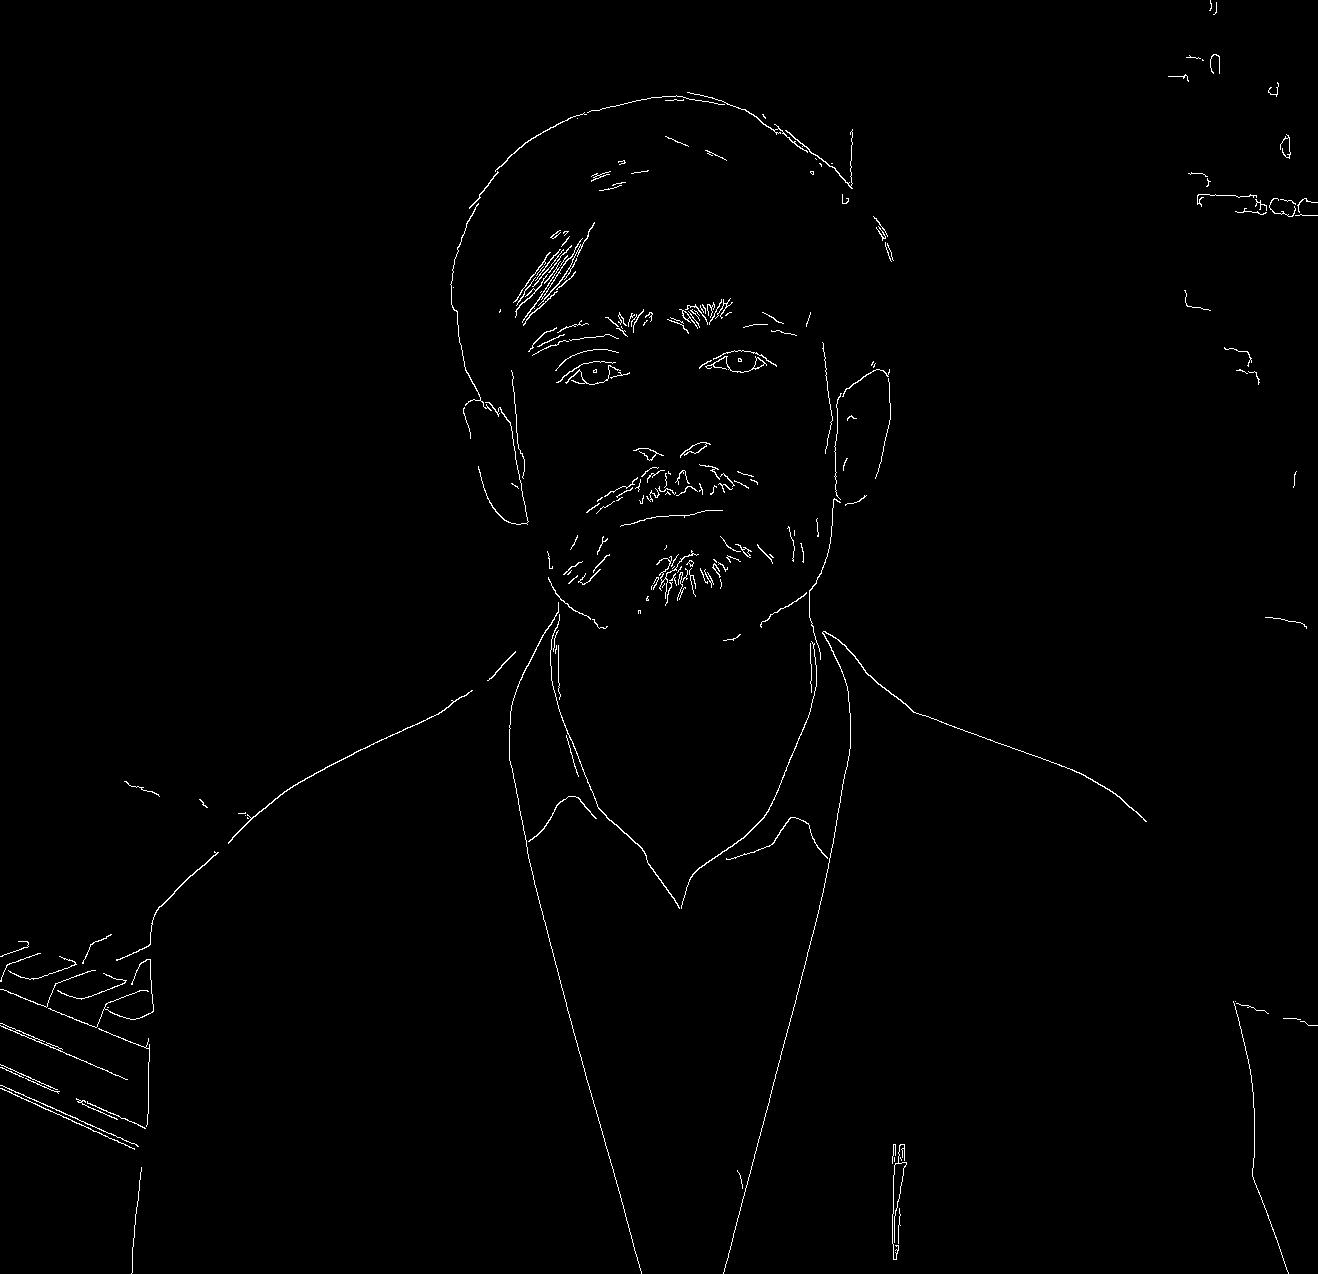

In [26]:
# Apply Canny Edge Detection
# The numbers 100 and 200 are the lower and upper thresholds for detecting strong vs. weak edges.
from google.colab.patches import cv2_imshow

edges = cv2.Canny(img_gray, 100, 200)

cv2_imshow(edges)

# plt.figure(figsize=(6, 6))
# plt.imshow(edges, cmap='gray')
# plt.axis('off')
# plt.title("Canny Edge Detection")
# plt.show()

## 4. AI in Action: Face Detection
Now let's do something advanced: detecting a human face.

Before modern Deep Learning, engineers used algorithms like **Haar Cascades**. These are pre-trained machine learning models that scan the image looking for specific patterns of light and dark that typically make up a human face (like the eyes being darker than the forehead).

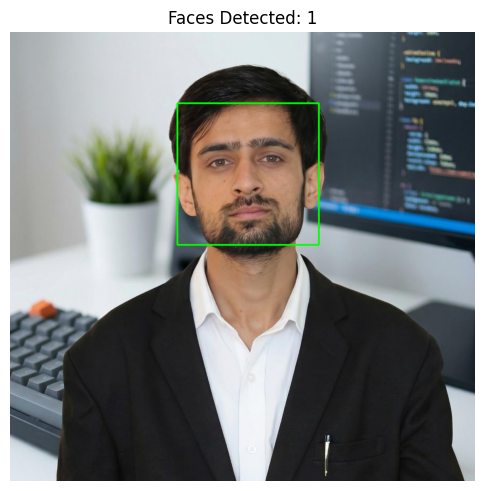

In [27]:
# Load the pre-trained Haar Cascade model for frontal faces
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Detect faces in the grayscale image
# scaleFactor compensates for faces being closer/further from the camera
# minNeighbors defines how many objects are detected near the current one before it declares the face found
faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5)

# Make a copy of the original RGB image to draw on
img_faces = img_rgb.copy()

# Loop over all detected faces and draw a rectangle around them
for (x, y, w, h) in faces:
    # cv2.rectangle(image, start_point, end_point, color, thickness)
    cv2.rectangle(img_faces, (x, y), (x+w, y+h), (0, 255, 0), 4)

plt.figure(figsize=(6, 6))
plt.imshow(img_faces)
plt.axis('off')
plt.title(f"Faces Detected: {len(faces)}")
plt.show()

## **Congratulations!**
You've just completed your first Computer Vision pipeline. You learned how to:
* Translate images into mathematical matrices.
* Manipulate color spaces for efficiency.
* Extract structural features (edges).
* Apply a machine learning model to detect complex objects (faces).

**Next Steps:** Try uploading your own image to Colab and changing the `image_url` to point to your file to see how the algorithms perform on different data!